## Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import GridSearchCV

## Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\K.Pavan Kumar\Downloads\PRCP-1009-CellphonePrice.zip")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## Dataset Information

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [5]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

## Missing Values

In [7]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

## Duplicate Values

In [8]:
df.duplicated().sum()

0

## Target Distribution

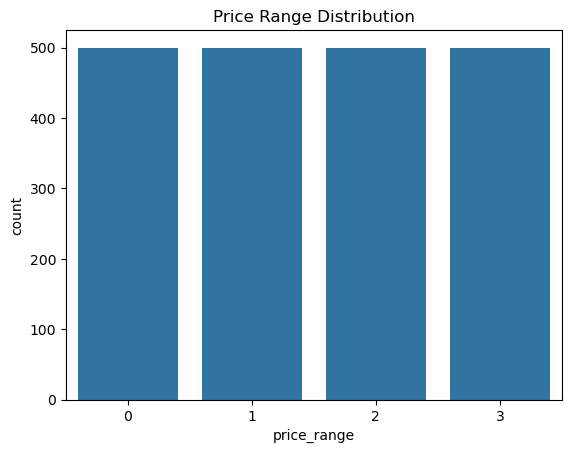

In [9]:
sns.countplot(x='price_range',data=df)

plt.title("Price Range Distribution")
plt.show()

## Correlation Heatmap

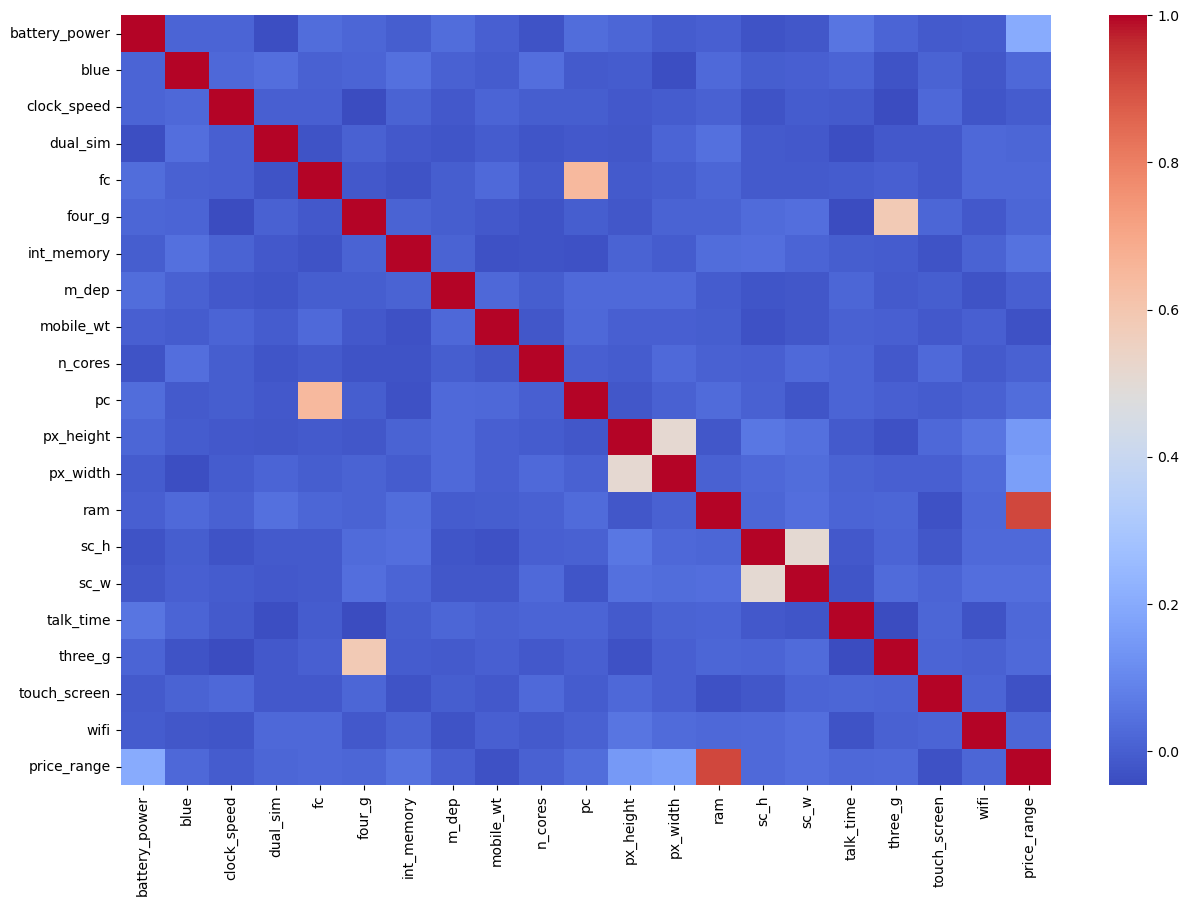

In [10]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(),annot=False,cmap='coolwarm')

plt.show()

## Histograms

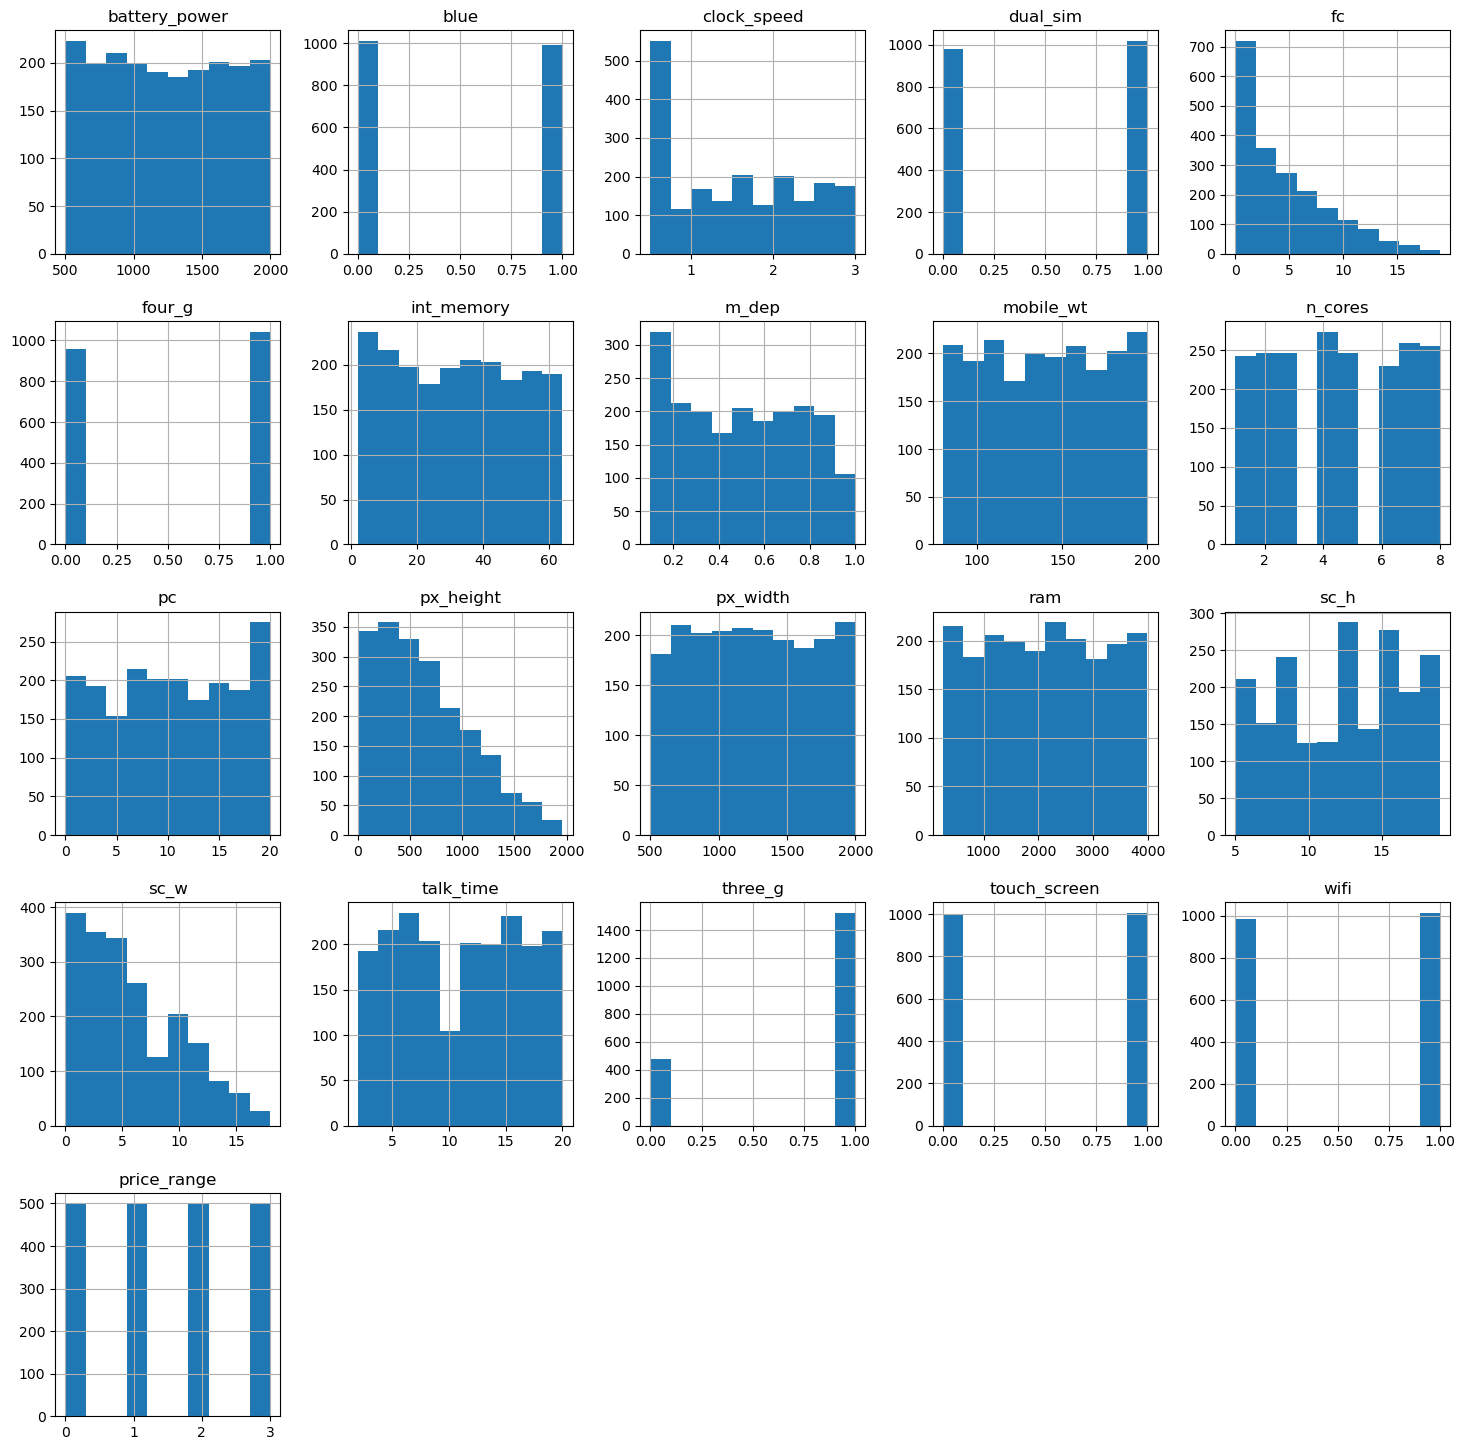

In [11]:
df.hist(figsize=(18,18))

plt.show()

## Boxplots

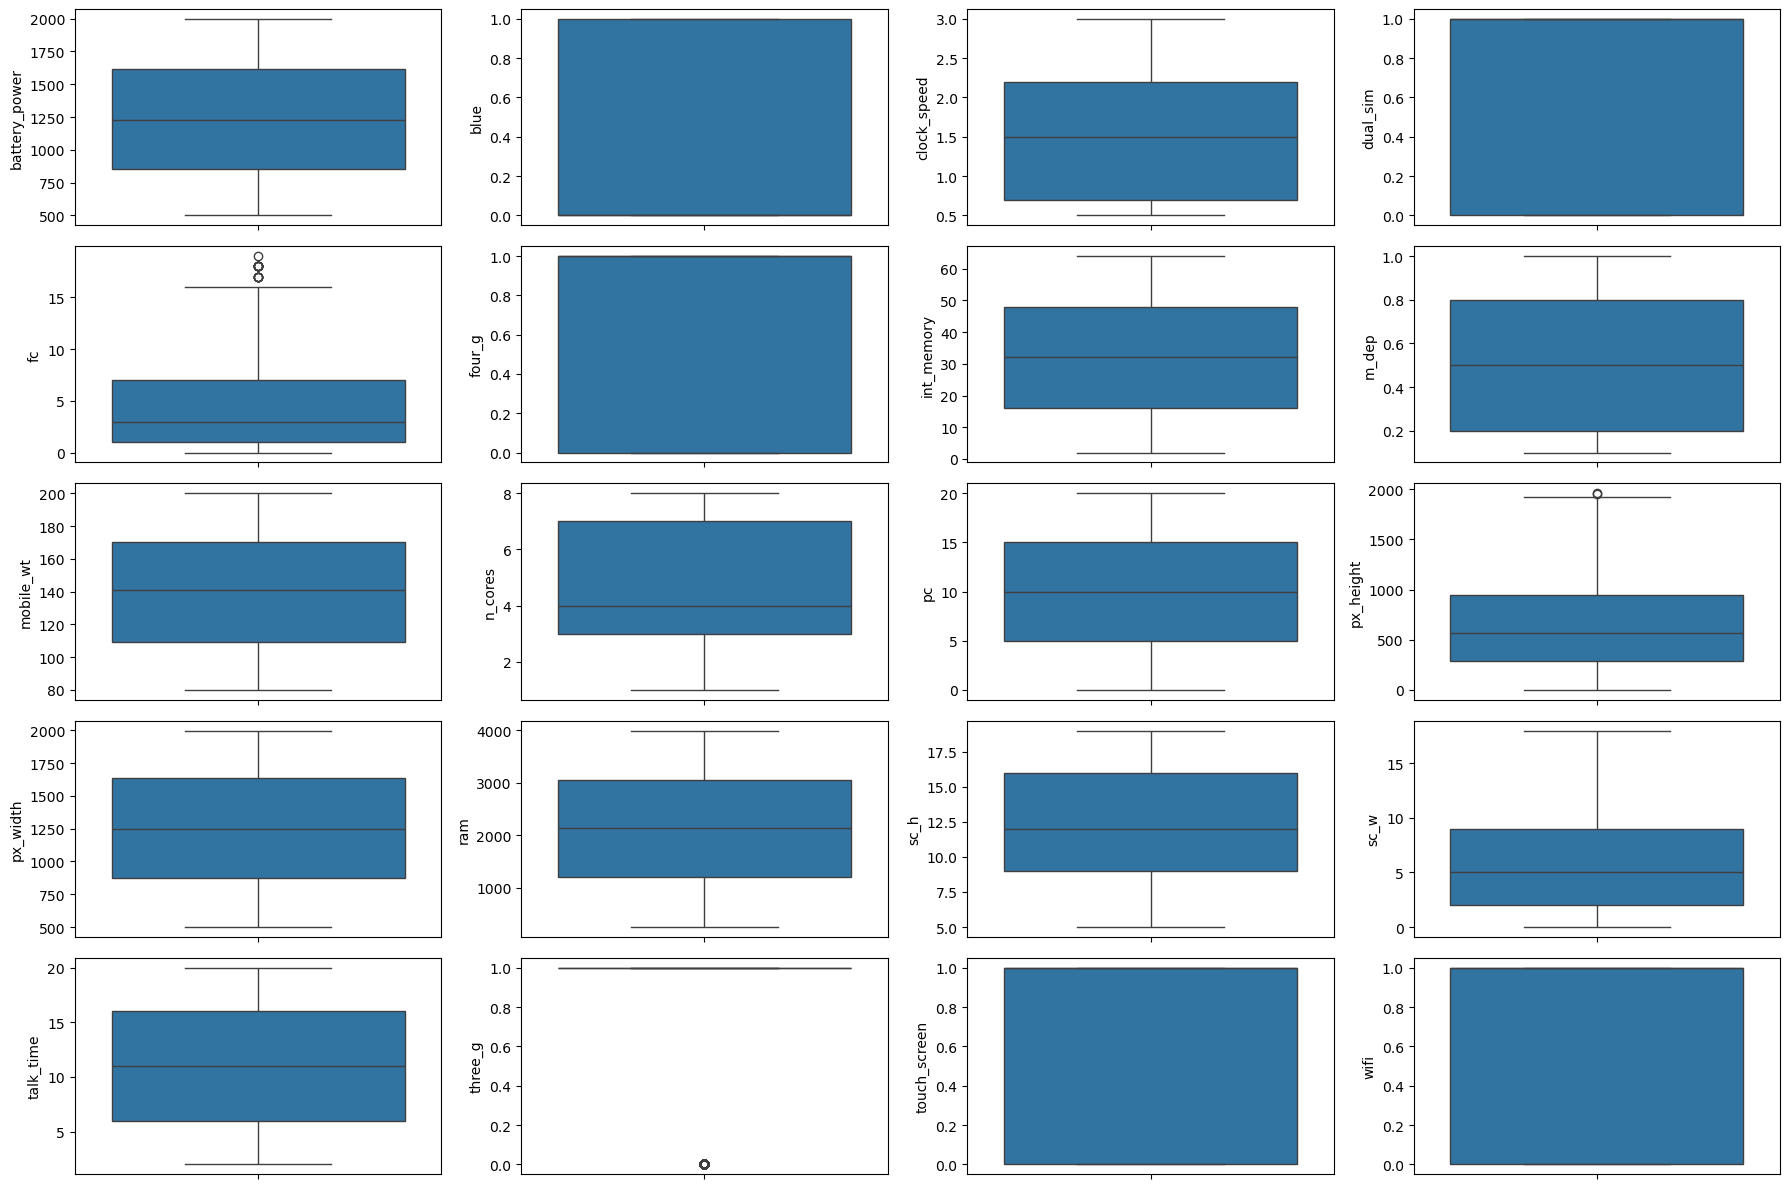

In [12]:
plt.figure(figsize=(18,12))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(5,4,i+1)
    sns.boxplot(df[col])

plt.tight_layout()

plt.show()

## Feature Importance using Random Forest

In [13]:
X=df.drop("price_range",axis=1)
y=df["price_range"]

rf=RandomForestClassifier(random_state=42)

rf.fit(X,y)

importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance=importance.sort_values(by="Importance",ascending=False)

importance

,Feature,Importance
13,ram,0.494163
0,battery_power,0.074602
12,px_width,0.057448
11,px_height,0.055640
8,mobile_wt,0.038960
6,int_memory,0.034699
16,talk_time,0.030347
15,sc_w,0.027892
10,pc,0.027459
14,sc_h,0.026547


## Plot Feature Importance

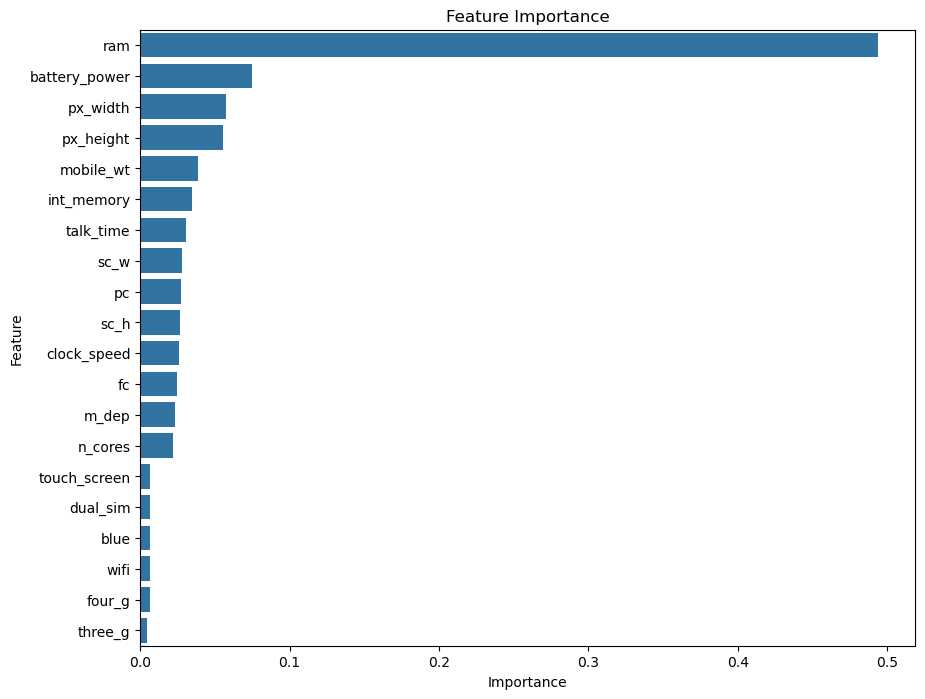

In [14]:
plt.figure(figsize=(10,8))

sns.barplot(data=importance,
            x="Importance",
            y="Feature")

plt.title("Feature Importance")

plt.show()

## Split Dataset

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.2,
random_state=42,
stratify=y)

##  Standardization

In [16]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

## Model Dictionary

In [17]:
models={

"Logistic Regression":LogisticRegression(),

"Decision Tree":DecisionTreeClassifier(random_state=42),

"Random Forest":RandomForestClassifier(random_state=42),

"Gradient Boosting":GradientBoostingClassifier(random_state=42),

"XGBoost":XGBClassifier(eval_metric='mlogloss')

}

## Model Comparison

In [18]:
result=[]

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    acc=accuracy_score(y_test,pred)

    result.append([name,acc])

results=pd.DataFrame(result,
                     columns=["Model","Accuracy"])

results.sort_values(by="Accuracy",
ascending=False)

,Model,Accuracy
0,Logistic Regression,0.9650
4,XGBoost,0.9350
3,Gradient Boosting,0.9125
2,Random Forest,0.8800
1,Decision Tree,0.8300


## Best Model

In [19]:
best_model=LogisticRegression(random_state=42)

best_model.fit(X_train,y_train)

prediction=best_model.predict(X_test)

## Accuracy

In [20]:
accuracy_score(y_test,prediction)

0.965

## Classification Report

In [21]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



## Confusion Matrix

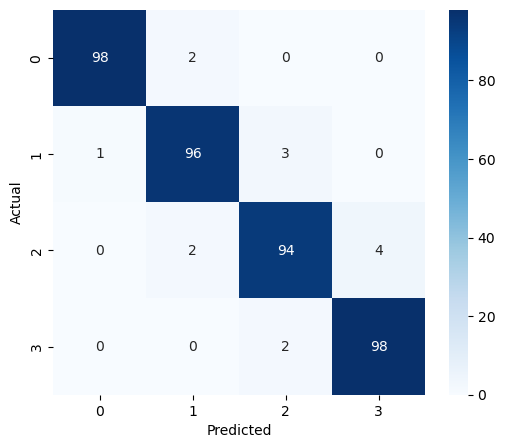

In [22]:
cm=confusion_matrix(y_test,prediction)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Hyperparameter Tuning

In [23]:
params={

'n_estimators':[100,200],

'max_depth':[5,10,None],

'min_samples_split':[2,5]

}

grid=GridSearchCV(

RandomForestClassifier(random_state=42),

params,

cv=5,

scoring='accuracy'

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

## Best Parameters

In [24]:
grid.best_params_

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

## Best Accuracy

In [25]:
grid.best_score_

0.8699999999999999

## Tuned Model

In [26]:
best_rf=grid.best_estimator_

pred=best_rf.predict(X_test)

accuracy_score(y_test,pred)

0.8825

## Final Classification Report

print(classification_report(y_test,pred))

## Predict New Mobile

In [27]:
sample=[[842,
0,
2.2,
0,
1,
0,
7,
0.6,
188,
2,
2,
20,
756,
2549,
9,
7,
19,
0,
0,
1]]

sample=scaler.transform(sample)

best_rf.predict(sample)

array([1], dtype=int64)

## Save Model

In [28]:
import joblib

joblib.dump(best_rf,"MobilePricePrediction.pkl")

joblib.dump(scaler,"Scaler.pkl")

['Scaler.pkl']

## Model Comparison Table

In [29]:
results

,Model,Accuracy
0,Logistic Regression,0.9650
1,Decision Tree,0.8300
2,Random Forest,0.8800
3,Gradient Boosting,0.9125
4,XGBoost,0.9350


In [30]:
print("""
----------Important Features----------

The model typically identifies these as the most influential features:

->Battery Power
->Pixel Width
->Pixel Height
->Internal Memory
->Screen Resolution
->Primary Camera
->Clock Speed """)


----------Important Features----------

The model typically identifies these as the most influential features:

->Battery Power
->Pixel Width
->Pixel Height
->Internal Memory
->Screen Resolution
->Primary Camera
->Clock Speed 


In [31]:
print(""" Challenges Faced Report
Challenge 1

No missing values were present, simplifying preprocessing.

Challenge 2

Feature scales differed significantly (e.g., RAM vs. Bluetooth), requiring feature scaling.

Challenge 3

Multiple algorithms performed differently, necessitating model comparison.

Challenge 4

Preventing overfitting in tree-based models was addressed using hyperparameter tuning with GridSearchCV.

Challenge 5

Interpreting feature importance was crucial for translating model outcomes into actionable business insights.""")

 Challenges Faced Report
Challenge 1

No missing values were present, simplifying preprocessing.

Challenge 2

Feature scales differed significantly (e.g., RAM vs. Bluetooth), requiring feature scaling.

Challenge 3

Multiple algorithms performed differently, necessitating model comparison.

Challenge 4

Preventing overfitting in tree-based models was addressed using hyperparameter tuning with GridSearchCV.

Challenge 5

Interpreting feature importance was crucial for translating model outcomes into actionable business insights.
